# Restaurants - classification problem

### Imports and setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, classification_report
from sklearn.base import clone

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

### Data loading and EDA
Loading the training data (containing the `status_closed` target) and the test data (which is predicted on at the very end).

Understanding the distribution of the dependent variable (`status_closed`) is the most critical step. The dataset is highly imbalanced, which suggests the use of SMOTE, Undersampling, and custom class weights.

Training data shape: (33296, 86)
Test data shape: (8325, 85)

Target Variable Distribution (status_closed):
status_closed
0    30028
1     3268
Name: count, dtype: int64

Percentage:
status_closed
0    90.185007
1     9.814993
Name: proportion, dtype: float64


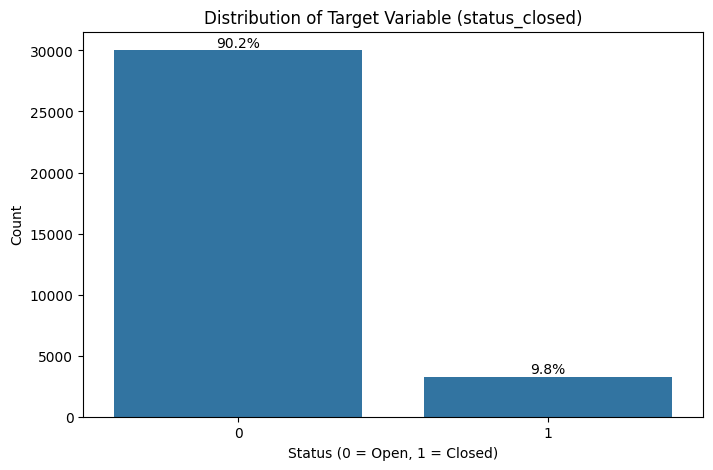

In [ ]:
train_df = pd.read_csv('data/restaurants_train.csv')
test_df = pd.read_csv('data/restaurants_test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}\n")

# Check the target variable imbalance
target_counts = train_df['status_closed'].value_counts()
target_props = train_df['status_closed'].value_counts(normalize=True) * 100

print("Target Variable Distribution (status_closed):")
print(target_counts)
print(f"\nPercentage:\n{target_props}")

# Visualize the distribution of the target variable
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_df, x='status_closed')
plt.title('Distribution of Target Variable (status_closed)')
plt.xlabel('Status (0 = Open, 1 = Closed)')
plt.ylabel('Count')

# Add percentage labels above bars
total = len(train_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_y() + p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

In real-world data missingness is the information itself. A lack of recent reviews or specific tags might be a strong indicator that a restaurant is struggling or already abandoned. Here, we analyze the sparsest columns. 
*(Note: ML pipelines will handle this later using `add_indicator=True` to capture the signal hidden in these missing values).*

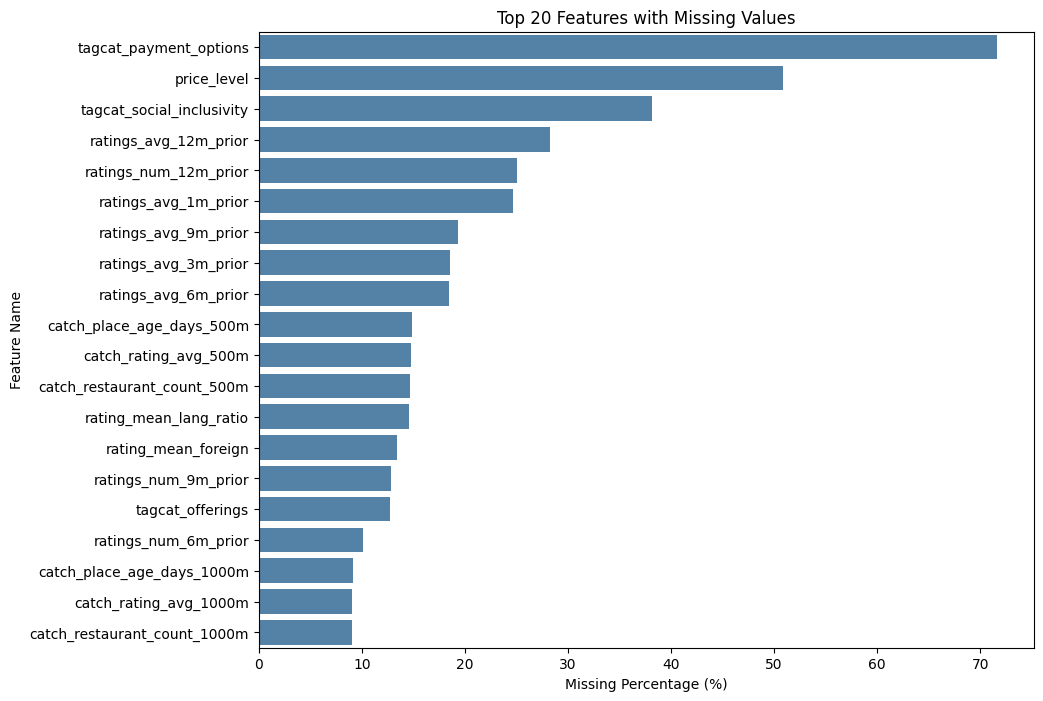

In [ ]:
missing_counts = train_df.isnull().sum()
missing_features = missing_counts[missing_counts > 0].sort_values(ascending=False)
missing_percentage = (missing_features / len(train_df)) * 100

# plot the top 20 features with the highest percentage of missing values
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_percentage.values[:20], y=missing_percentage.index[:20], color='steelblue')
plt.title('Top 20 Features with Missing Values')
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Feature Name')
plt.show()

Examination of how categorical attributes like price tier (`price_level`) or the presence of a profile photo (`has_photo`) impact the probability of a restaurant closing.

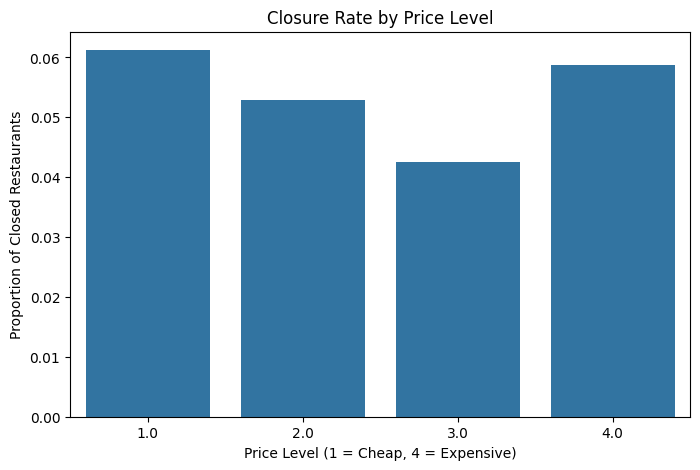

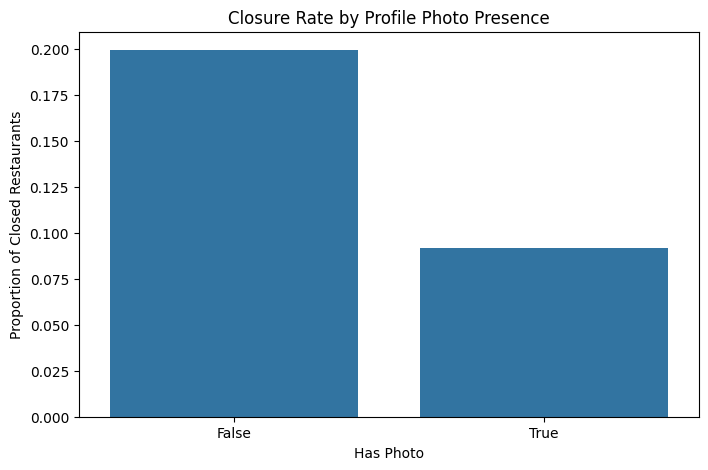

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=train_df, x='price_level', y='status_closed', errorbar=None)
plt.title('Closure Rate by Price Level')
plt.xlabel('Price Level (1 = Cheap, 4 = Expensive)')
plt.ylabel('Proportion of Closed Restaurants')
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=train_df, x='has_photo', y='status_closed', errorbar=None)
plt.title('Closure Rate by Profile Photo Presence')
plt.xlabel('Has Photo')
plt.ylabel('Proportion of Closed Restaurants')
plt.show()

Continuous variables like ratings often suffer from severe skewness (e.g., a few restaurants have tens of thousands of reviews, while most have very few). The density of these features is compared between open and closed restaurants to see if they offer predictive power.

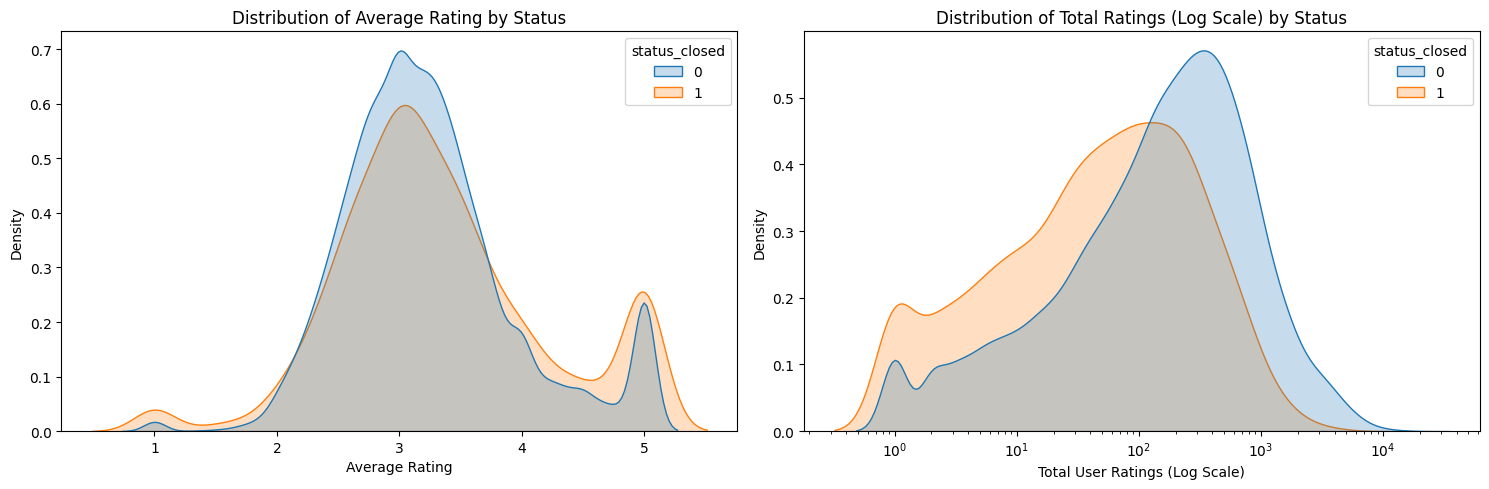

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Average Rating
sns.kdeplot(data=train_df, x='rating_avg', hue='status_closed', common_norm=False, fill=True, ax=axes[0])
axes[0].set_title('Distribution of Average Rating by Status')
axes[0].set_xlabel('Average Rating')

# Plot 2: Total User Ratings
sns.kdeplot(data=train_df, x='user_ratings_total', hue='status_closed', common_norm=False, fill=True, log_scale=True, ax=axes[1])
axes[1].set_title('Distribution of Total Ratings (Log Scale) by Status')
axes[1].set_xlabel('Total User Ratings (Log Scale)')

plt.tight_layout()
plt.show()

### Preprocessing

To prevent data leakage and keep the code clean, blueprint for data transformation was defined using `ColumnTransformer`. 

* **Numeric Features:** Missing values are imputed with the median, and a missing indicator is added. We then apply a `PowerTransformer` (Yeo-Johnson) to fix the severe skewness observed in our EDA.
* **Categorical Features:** Missing values are explicitly flagged as 'Unknown' so the model can learn from them, followed by standard One-Hot Encoding.

In [ ]:
#separate features and target from the RAW data
X_train_raw = train_df.drop(columns=['restaurant_id', 'status_closed'])
y_train_raw = train_df['status_closed']
X_test_kaggle = test_df.drop(columns=['restaurant_id'])

# identify Column Types
cat_cols = ['category_top20', 'price_level', 'has_photo', 'type_meal_takeaway', 
            'type_meal_delivery', 'type_bar', 'type_cafe', 'type_night_club', 
            'weekends_only', 'workdays_only', 'affiliated']

num_cols = [col for col in X_train_raw.columns if col not in cat_cols]

# create the pipeline blueprint
# For numeric: impute with median, flag missings, and fix skewness
numeric_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)), 
    ('power_transform', PowerTransformer(method='yeo-johnson')) 
])

# For categorical: impute with mode, then One-Hot Encode
categorical_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# combine into a single preprocessor step
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

# KNN-specific preprocessor: MinMaxScaler bounds features to [0,1]
numeric_transformer_knn = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', MinMaxScaler())
])
preprocessor_knn = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_knn, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

### Train/Test split

In [ ]:
# split the data randomly into train (80%) and validation (20%)
# stratify to maintain the 10:1 target distribution
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, 
    y_train_raw, 
    test_size=0.2, 
    stratify=y_train_raw, 
    random_state=123
)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

Training set size: (26636, 84)
Validation set size: (6660, 84)


## Defining and Training the Models

Here is the test of three fundamentally different ML1 algorithms. For each, `GridSearchCV` was used with 5-fold Stratified Cross-Validation to find the optimal hyperparameters.

### Logistic Regression / Elastic net

### 6.1 Elastic Net (Regularized Logistic Regression)
Elastic Net combines L1 (LASSO) and L2 (Ridge) penalties. Because linear models struggle with severe imbalance, `SMOTE` was integrated directly into the pipeline to synthesize minority class examples during training. (aprox. 210 minutes)

In [ ]:
# build the Pipeline with a cloned preprocessor
master_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', SMOTE(random_state=123)),
    ('model', LogisticRegression(solver='saga', max_iter=10000, random_state=123))
])

# hyperparameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1.0, 5, 10.0],
    'model__l1_ratio': [0, 0.1, 0.5, 0.9, 1.0],
    'smote__sampling_strategy': [0.3, 0.5, 1.0]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

grid_search = GridSearchCV(
    estimator=master_pipeline,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Training Master Pipeline with Missing Indicators & PowerTransforms...")
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV Balanced Accuracy: {grid_search.best_score_:.4f}")

Training Master Pipeline with Missing Indicators & PowerTransforms...
Best Parameters: {'model__C': 0.01, 'model__l1_ratio': 0.1, 'smote__sampling_strategy': 1.0}
Best CV Balanced Accuracy: 0.6775


### Logistic Regression with class_weight='balanced' (no SMOTE)
(aprox 60 minutes)

In [6]:
# Alternative: class_weight='balanced' instead of SMOTE
balanced_lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('model', LogisticRegression(solver='saga', max_iter=10000, random_state=123, class_weight='balanced'))
])

param_grid_balanced = {
    'model__C': [0.01, 0.1, 1.0, 5, 10.0],
    'model__l1_ratio': [0, 0.1, 0.5, 0.9, 1.0]
}

grid_balanced_lr = GridSearchCV(
    estimator=balanced_lr_pipeline,
    param_grid=param_grid_balanced,
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Training class_weight='balanced' Elastic Net (no SMOTE)...")
grid_balanced_lr.fit(X_train, y_train)

print("Best Parameters:", grid_balanced_lr.best_params_)
print(f"Best CV Balanced Accuracy: {grid_balanced_lr.best_score_:.4f}")

Training class_weight='balanced' Elastic Net (no SMOTE)...
Best Parameters: {'model__C': 0.1, 'model__l1_ratio': 1.0}
Best CV Balanced Accuracy: 0.6797


### K-nearest neighbours (KNN)

KNN is a distance-based, non-parametric model. Like Elastic Net, `SMOTE` was used to balance the data space. Different values of `K` were tested, distance weights, and distance metrics (Manhattan `p=1` vs Euclidean `p=2`). (aprox. 8 minutes)

In [ ]:
# build the KNN pipeline with a cloned preprocessor
knn_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor_knn)),
    ('smote', SMOTE(random_state=123)),
    ('model', KNeighborsClassifier())
])

# 2. hyperparameter grid
param_grid_knn = {
    'model__n_neighbors': [5, 15, 30, 50],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2],
    'smote__sampling_strategy': [0.3, 0.5, 1.0]
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid_knn,
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Searching for optimal SMOTE + KNN...")
knn_search.fit(X_train, y_train)

print("Best Parameters:", knn_search.best_params_)
print(f"Best CV Balanced Accuracy: {knn_search.best_score_:.4f}")

Searching for optimal SMOTE + KNN...
Best Parameters: {'model__n_neighbors': 50, 'model__p': 2, 'model__weights': 'distance', 'smote__sampling_strategy': 0.5}
Best CV Balanced Accuracy: 0.6320


### Support Vector Machine (SVM)

SVM attempts to find the optimal hyperplane separating open and closed restaurants. SVM training scales quadratically ($O(n^2)$). To prevent hours of computation time on our 33k rows, `RandomUnderSampler` was used in one of the approaches to shrink the majority class. In the second, procedure was completed in the whole data with `class_weight='balanced'` (take 2 hours to complete).

In [ ]:
# build the SVM pipeline with a cloned preprocessor
svm_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
#    ('undersampler', RandomUnderSampler(random_state=123)),
    ('model', SVC(random_state=123, probability=True, class_weight='balanced')) 
])

# hyperparameter grid
param_grid_svm = {
    'model__C': [0.1, 1.0, 10.0],
    'model__gamma': ['scale', 'auto'],
    'model__kernel': ['rbf'] 
}

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Searching for optimal SVM... (This may take a while!)")
svm_search.fit(X_train, y_train)

print("Best Parameters:", svm_search.best_params_)
print(f"Best CV Balanced Accuracy: {svm_search.best_score_:.4f}")

Searching for optimal SVM... (This may take a while!)
Best Parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV Balanced Accuracy: 0.6744


In [ ]:
# build the SVM Pipeline
svm_pipeline = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('undersampler', RandomUnderSampler(random_state=123)),
    ('model', SVC(random_state=123, probability=True))
])

# hyperparameter grid
param_grid_svm = {
    'model__C': [0.1, 1.0, 10.0],
    'model__gamma': ['scale', 'auto'],
    'model__kernel': ['rbf'] 
}

svm_search_u = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy',
    cv=cv5,
    n_jobs=-1
)

print("Searching for optimal Undersampled SVM...")
svm_search_u.fit(X_train, y_train)

print("Best Parameters:", svm_search_u.best_params_)
print(f"Best CV Balanced Accuracy: {svm_search_u.best_score_:.4f}")

Searching for optimal Undersampled SVM...
Best Parameters: {'model__C': 1.0, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best CV Balanced Accuracy: 0.6704


### Model Evaluaton

In this final phase:
1. Automatically identified the best-performing model from the three GridSearches.
2. Threshold Tuning: The default 0.5 probability threshold is rarely optimal for imbalanced datasets. `cross_val_predict` was checked on the training set to find the exact threshold that maximizes Balanced Accuracy.
3. Evaluate the optimized model on our untouched Validation set.
4. Retrain the winning model on the entire dataset and generate the final submission CSV.

In [ ]:
searches = {
    'Elastic Net (SMOTE)': grid_search,
    'Elastic Net (balanced)': grid_balanced_lr,
    'KNN': knn_search,
    'SVM (RBF, balanced)': svm_search,
    'SVM (RBF, undersampled)': svm_search_u
}

best_overall_name = ""
best_overall_score = 0
best_model = None

for name, search_obj in searches.items():
    if search_obj.best_score_ > best_overall_score:
        best_overall_score = search_obj.best_score_
        best_model = search_obj.best_estimator_
        best_overall_name = name

print("-" * 30)
print(f"BEST MODEL: {best_overall_name}")
print(f"Best CV Balanced Accuracy: {best_overall_score:.4f}")
print("-" * 30)

# HRESHOLD TUNING
# use of cross_val_predict on X_train to get unbiased, out-of-fold probabilities.
print("\nCalculating Out-Of-Fold probabilities for leak-free threshold tuning...")
oof_train_probs = cross_val_predict(best_model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

thresholds = np.linspace(0.2, 0.8, 100)
best_threshold = 0.5
best_train_bacc = 0

for t in thresholds:
    custom_preds = (oof_train_probs >= t).astype(int)
    score = balanced_accuracy_score(y_train, custom_preds)
    if score > best_train_bacc:
        best_train_bacc = score
        best_threshold = t

print(f"Optimal Threshold (Found via CV on Train): {best_threshold:.3f}")

# evaluate on validation set
val_probs = best_model.predict_proba(X_val)[:, 1]
final_val_preds = (val_probs >= best_threshold).astype(int)

print(f"\nDefault 0.5 Threshold Val Balanced Accuracy: {balanced_accuracy_score(y_val, best_model.predict(X_val)):.4f}")
print(f"OPTIMIZED Threshold ({best_threshold:.3f}) Val Balanced Accuracy: {balanced_accuracy_score(y_val, final_val_preds):.4f}")


# FINAL SUBMISSION PREPARATION

print(f"\nRetraining {best_overall_name} on the FULL training dataset...")
best_model.fit(X_train_raw, y_train_raw)

# generate probabilities for the test set
test_probs = best_model.predict_proba(X_test_kaggle)[:, 1]

# apply our highly optimized threshold
final_test_predictions = (test_probs >= best_threshold).astype(int)

# create submission dataframe
submission = pd.DataFrame({
    'restaurant_id': test_df['restaurant_id'],
    'status_closed': final_test_predictions
})

# save to CSV
submission_filename = f'submission_best_{best_overall_name.replace(" ", "_")}.csv'
submission.to_csv(submission_filename, index=False)
print(f"Submission saved to {submission_filename}!")

------------------------------
BEST MODEL: Elastic Net (balanced)
Best CV Balanced Accuracy: 0.6797
------------------------------

Calculating Out-Of-Fold probabilities for leak-free threshold tuning...
Optimal Threshold (Found via CV on Train): 0.479

Default 0.5 Threshold Val Balanced Accuracy: 0.6759
OPTIMIZED Threshold (0.479) Val Balanced Accuracy: 0.6741

Retraining Elastic Net (balanced) on the FULL training dataset...
Submission saved to submission_best_Elastic_Net_(balanced).csv!
